# 02. Prepare SAMPLE data and coarse-grain it

This notebook prepares monthly default-count data in the `SAMPLE.csv` format and applies the Code 02 k-month coarse-graining rule.

Input format:

```text
date,bonds,defaulted
```

Important: by default this notebook does **not** overwrite `data/SAMPLE.csv`. To create a low-fidelity synthetic sample, set `GENERATE_SYNTHETIC_SAMPLE = True`.

In [1]:
# ============================================================
# Setup
# ============================================================

SEED = 123
GENERATE_SYNTHETIC_SAMPLE = False  # Set True only when you want to create a demo SAMPLE.csv.
OVERWRITE_SAMPLE = False           # Keep False to protect an existing true SAMPLE.csv.

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display

random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path('./data')
PDATA_DIR = Path('./pdata')
FIG_DIR = Path('./figures')

for d in [DATA_DIR, PDATA_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

K_LIST = [1, 2, 3, 4, 6, 12]
P_MIN = 1e-8
P_MAX = 1.0 - 1e-8

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

plt.rcParams.update({
    'figure.figsize': (6.8, 4.2),
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10.5,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [2]:
# ============================================================
# Optional: generate a low-fidelity synthetic SAMPLE.csv
# ============================================================

sample_path = DATA_DIR / 'SAMPLE.csv'

if GENERATE_SYNTHETIC_SAMPLE:
    if sample_path.exists() and not OVERWRITE_SAMPLE:
        raise FileExistsError(
            f'{sample_path} already exists. Set OVERWRITE_SAMPLE=True only if you intentionally want to overwrite it.'
        )

    T = 489
    dates = pd.date_range(start='1981-01-31', periods=T, freq='M')
    rng = np.random.default_rng(SEED)

    trend = np.linspace(1350, 6250, T)
    seasonal = 60.0 * np.sin(2.0 * np.pi * np.arange(T) / 60.0)
    noise = rng.normal(0.0, 35.0, T)
    bonds = np.maximum(500, np.round(trend + seasonal + noise)).astype(int)

    mu = norm.ppf(0.0012)
    phi = 0.94
    sigma_eta = 0.075
    x = np.zeros(T)
    x[0] = rng.normal(0.0, sigma_eta / np.sqrt(1.0 - phi**2))
    for t in range(1, T):
        x[t] = phi * x[t-1] + rng.normal(0.0, sigma_eta)

    def add_bump(center, width, amp):
        idx = np.arange(T)
        return amp * np.exp(-0.5 * ((idx - center) / width)**2)

    z = mu + x
    z += add_bump(110, 10, 0.55)
    z += add_bump(255, 14, 0.70)
    z += add_bump(385, 16, 0.65)

    p = np.clip(norm.cdf(z), P_MIN, 0.08)
    defaulted = rng.binomial(bonds, p)

    sample = pd.DataFrame({
        'date': dates.strftime('%Y/%-m/%-d'),
        'bonds': bonds.astype(int),
        'defaulted': defaulted.astype(int),
    })
    sample.to_csv(sample_path, index=False)
    print('Saved synthetic sample:', sample_path)
else:
    print('Synthetic generation skipped. Using existing:', sample_path)

if not sample_path.exists():
    raise FileNotFoundError(
        f'{sample_path} was not found. Place SAMPLE.csv under ./data/, or set GENERATE_SYNTHETIC_SAMPLE=True.'
    )

Synthetic generation skipped. Using existing: data\SAMPLE.csv


In [3]:
# ============================================================
# Load SAMPLE.csv and prepare monthly ALL data
# ============================================================

df_sample = pd.read_csv(sample_path)
required_cols = {'date', 'bonds', 'defaulted'}
missing = required_cols - set(df_sample.columns)
if missing:
    raise ValueError(f'SAMPLE.csv is missing required columns: {missing}')

df_sample['date'] = pd.to_datetime(df_sample['date'])
df_sample = df_sample.sort_values('date').reset_index(drop=True)

# Add columns used by the original Code 02 aggregation workflow.
df_monthly_all = df_sample.copy()
df_monthly_all['year'] = df_monthly_all['date'].dt.year
df_monthly_all['month'] = df_monthly_all['date'].dt.month
df_monthly_all['quarter'] = df_monthly_all['date'].dt.quarter
df_monthly_all['half'] = np.where(df_monthly_all['month'] <= 6, 1, 2)
df_monthly_all['sector'] = 'ALL'
df_monthly_all['default_rate'] = df_monthly_all['defaulted'] / df_monthly_all['bonds']

display(df_monthly_all.head())
display(df_monthly_all.tail())
print(df_monthly_all.shape)

,date,bonds,defaulted,year,month,quarter,half,sector,default_rate
0,1981-01-31,1342,0,1981,1,1,1,ALL,0.000000
1,1981-02-28,1353,1,1981,2,1,1,ALL,0.000739
2,1981-03-31,1359,0,1981,3,1,1,ALL,0.000000
3,1981-04-30,1367,0,1981,4,2,1,ALL,0.000000
4,1981-05-31,1370,0,1981,5,2,1,ALL,0.000000


,date,bonds,defaulted,year,month,quarter,half,sector,default_rate
484,2021-05-31,6204,4,2021,5,2,1,ALL,0.000645
485,2021-06-30,6224,2,2021,6,2,1,ALL,0.000321
486,2021-07-31,6248,6,2021,7,3,2,ALL,0.000960
487,2021-08-31,6255,3,2021,8,3,2,ALL,0.000480
488,2021-09-30,6253,1,2021,9,3,2,ALL,0.000160


(489, 9)


In [4]:
# ============================================================
# k-month aggregation
#
# Definition inherited from Code 02:
#   n = number of bonds at the first month of the block
#   L = total number of defaults during the following k months
# ============================================================

def aggregate_k_month_all(df_monthly_all, k, drop_incomplete=True):
    """
    Coarse-grain monthly ALL data into non-overlapping k-month blocks.

    This is the single data coarse-graining rule used by the public workflow.
    Code 03 and Code 04 read the CSV produced here instead of redefining
    the observed-data aggregation.
    """
    d = df_monthly_all.sort_values('date').reset_index(drop=True).copy()
    rows = []
    n_blocks = len(d) // k if drop_incomplete else int(np.ceil(len(d) / k))

    for b in range(n_blocks):
        block = d.iloc[b*k:(b+1)*k].copy()
        if drop_incomplete and len(block) < k:
            continue

        first = block.iloc[0]
        last = block.iloc[-1]
        n_start = float(first['bonds'])
        L_sum = float(block['defaulted'].sum())

        rows.append({
            'k_month': int(k),
            'block_id': int(b),
            'start_date': first['date'],
            'end_date': last['date'],
            'start_year': int(first['year']),
            'start_month': int(first['month']),
            'end_year': int(last['year']),
            'end_month': int(last['month']),
            'n_months': int(len(block)),
            'n': n_start,
            'L': L_sum,
            'default_rate': L_sum / n_start if n_start > 0 else np.nan,
            'L_per_month': L_sum / k,
            'default_rate_per_month': (L_sum / n_start) / k if n_start > 0 else np.nan,
            'annualized_default_rate': (12.0 / k) * (L_sum / n_start) if n_start > 0 else np.nan,
            'n_end': float(last['bonds']),
            'n_mean_in_block': float(block['bonds'].mean()),
            'n_sum_in_block': float(block['bonds'].sum()),
        })

    return pd.DataFrame(rows)

In [5]:
# ============================================================
# Build k-month data using the Code 02 aggregation function
# ============================================================

df_kmonth_list = []
for k in K_LIST:
    df_k = aggregate_k_month_all(
        df_monthly_all=df_monthly_all,
        k=k,
        drop_incomplete=True,
    )
    df_kmonth_list.append(df_k)

df_kmonth = pd.concat(df_kmonth_list, ignore_index=True)

display(df_kmonth.head())
display(df_kmonth.groupby('k_month').size().rename('T').reset_index())

,k_month,block_id,start_date,end_date,start_year,start_month,end_year,end_month,n_months,n,L,default_rate,L_per_month,default_rate_per_month,annualized_default_rate,n_end,n_mean_in_block,n_sum_in_block
0,1,0,1981-01-31,1981-01-31,1981,1,1981,1,1,1342.0,0.0,0.000000,0.0,0.000000,0.000000,1342.0,1342.0,1342.0
1,1,1,1981-02-28,1981-02-28,1981,2,1981,2,1,1353.0,1.0,0.000739,1.0,0.000739,0.008869,1353.0,1353.0,1353.0
2,1,2,1981-03-31,1981-03-31,1981,3,1981,3,1,1359.0,0.0,0.000000,0.0,0.000000,0.000000,1359.0,1359.0,1359.0
3,1,3,1981-04-30,1981-04-30,1981,4,1981,4,1,1367.0,0.0,0.000000,0.0,0.000000,0.000000,1367.0,1367.0,1367.0
4,1,4,1981-05-31,1981-05-31,1981,5,1981,5,1,1370.0,0.0,0.000000,0.0,0.000000,0.000000,1370.0,1370.0,1370.0


,k_month,T
0,1,489
1,2,244
2,3,163
3,4,122
4,6,81
5,12,40


In [6]:
# ============================================================
# Summary statistics for k-month data
# ============================================================

summary_k = (
    df_kmonth
    .groupby('k_month')
    .agg(
        T=('L', 'size'),
        start_date=('start_date', 'min'),
        end_date=('end_date', 'max'),
        mean_n=('n', 'mean'),
        mean_L=('L', 'mean'),
        var_L=('L', 'var'),
        mean_default_rate=('default_rate', 'mean'),
        var_default_rate=('default_rate', 'var'),
        mean_default_rate_per_month=('default_rate_per_month', 'mean'),
        var_default_rate_per_month=('default_rate_per_month', 'var'),
    )
    .reset_index()
)

base = summary_k.query('k_month == 1').iloc[0]
summary_k['var_independent'] = base['var_default_rate_per_month'] / summary_k['k_month']
summary_k['var_ratio_to_independent'] = summary_k['var_default_rate_per_month'] / summary_k['var_independent']

display(summary_k)

,k_month,T,start_date,end_date,mean_n,mean_L,var_L,mean_default_rate,var_default_rate,mean_default_rate_per_month,var_default_rate_per_month,var_independent,var_ratio_to_independent
0,1,489,1981-01-31,2021-09-30,3912.208589,5.012270,28.327718,0.001231,0.000001,0.001231,1.349071e-06,1.349071e-06,1.000000
1,2,244,1981-01-31,2021-08-31,3901.569672,10.040984,97.981853,0.002468,0.000004,0.001234,1.054596e-06,6.745355e-07,1.563441
2,3,163,1981-01-31,2021-09-30,3901.895706,15.036810,214.122093,0.003697,0.000009,0.001232,9.691985e-07,4.496903e-07,2.155257
3,4,122,1981-01-31,2021-08-31,3890.565574,20.081967,346.257689,0.004946,0.000014,0.001236,8.866425e-07,3.372678e-07,2.628898
4,6,81,1981-01-31,2021-06-30,3874.197531,30.135802,752.268827,0.007432,0.000030,0.001239,8.199565e-07,2.248452e-07,3.646761
5,12,40,1981-01-31,2020-12-31,3820.475000,60.150000,2779.258974,0.014962,0.000102,0.001247,7.068487e-07,1.124226e-07,6.287426


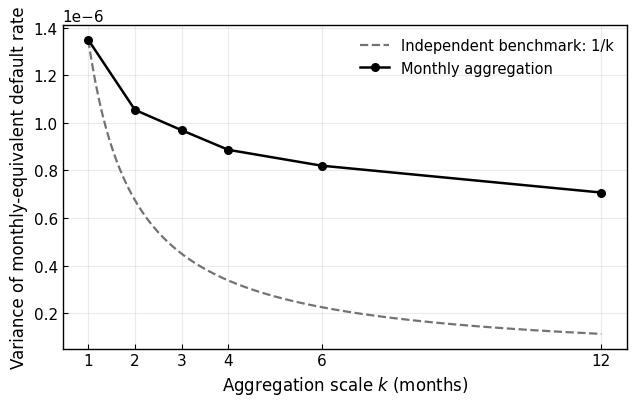

In [7]:
# ============================================================
# Publication-style diagnostic plot: variance scaling
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 4.2))

x_grid = np.linspace(1, max(K_LIST), 300)
var_1m = float(summary_k.query('k_month == 1')['var_default_rate_per_month'].iloc[0])
ax.plot(x_grid, var_1m / x_grid, linestyle='--', linewidth=1.6, color='0.45', label='Independent benchmark: 1/k')

ax.plot(
    summary_k['k_month'],
    summary_k['var_default_rate_per_month'],
    marker='o', linestyle='-', linewidth=1.8, markersize=5.5,
    color='black', label='Monthly aggregation'
)

ax.set_xlabel('Aggregation scale $k$ (months)')
ax.set_ylabel('Variance of monthly-equivalent default rate')
ax.set_xticks(K_LIST)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()

fig.savefig(FIG_DIR / 'fig02_variance_scaling.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig02_variance_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# Save processed aggregation data for Code 03 and Code 04
# ============================================================

PDATA_DIR.mkdir(parents=True, exist_ok=True)

df_monthly_all.to_csv(PDATA_DIR / 'SP_monthly_ALL.csv', index=False)
df_kmonth.to_csv(PDATA_DIR / 'SP_monthly_ALL_kmonth.csv', index=False)
summary_k.to_csv(PDATA_DIR / 'summary_SP_monthly_ALL_kmonth.csv', index=False)

print('Saved files:')
print(PDATA_DIR / 'SP_monthly_ALL.csv')
print(PDATA_DIR / 'SP_monthly_ALL_kmonth.csv')
print(PDATA_DIR / 'summary_SP_monthly_ALL_kmonth.csv')

Saved files:
pdata\SP_monthly_ALL.csv
pdata\SP_monthly_ALL_kmonth.csv
pdata\summary_SP_monthly_ALL_kmonth.csv
